In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as pltt

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
train_dir = '/content/drive/MyDrive/tensor_Practice/dataset/train'
test_dir = '/content/drive/MyDrive/tensor_Practice/dataset/test'

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 1275 images belonging to 2 classes.
Found 182 images belonging to 2 classes.


In [12]:
model = Sequential()

# Layer 1: Convolutional + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 2: Convolutional + MaxPooling
model.add(Conv2D(256, (5, 5), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 3: Convolutional
model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))

# Layer 4: Convolutional
model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))

# Layer 5: Convolutional + MaxPooling
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Flatten the output for the Fully Connected layers
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_generator.num_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 35, 35, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 17, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,979,394 (114.36 MB)

 Trainable params: 29,978,690 (114.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [14]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=2,
    validation_data=test_generator
)

Epoch 1/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 513s 13s/step - accuracy: 0.6306 - loss: 2.6566 - val_accuracy: 0.4615 - val_loss: 0.7041
Epoch 2/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 349ms/step - accuracy: 0.6722 - loss: 0.6896 - val_accuracy: 0.7143 - val_loss: 0.6266


In [15]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.7143 - loss: 0.6266
Test accuracy: 0.7142857313156128


In [16]:
# Save the model
model.save('alexnet_custom_dataset_model.h5')

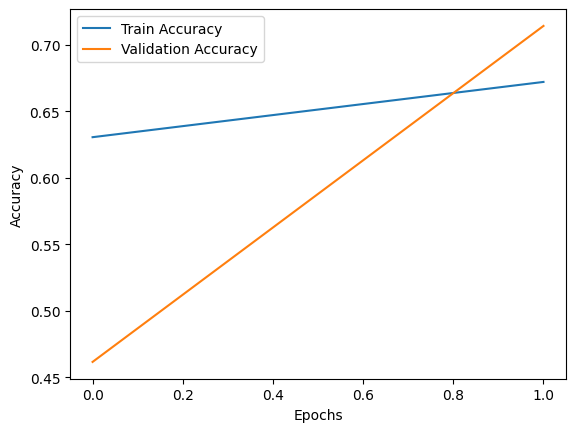

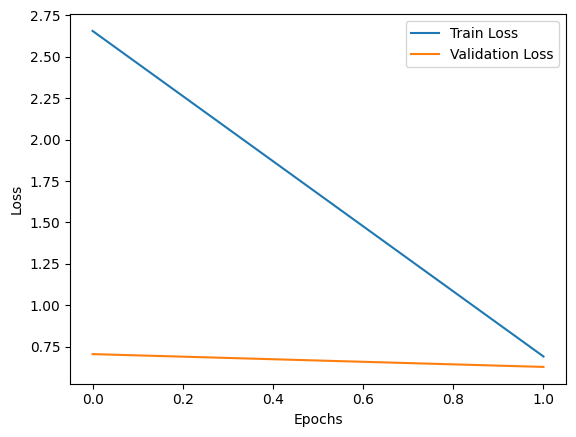

In [18]:
# Visualize Training History
pltt.plot(history.history['accuracy'], label='Train Accuracy')
pltt.plot(history.history['val_accuracy'], label='Validation Accuracy')
pltt.xlabel('Epochs')
pltt.ylabel('Accuracy')
pltt.legend()
pltt.show()

pltt.plot(history.history['loss'], label='Train Loss')
pltt.plot(history.history['val_loss'], label='Validation Loss')
pltt.xlabel('Epochs')
pltt.ylabel('Loss')
pltt.legend()
pltt.show()

In [26]:
import numpy as np

# Prediction Code
def predict_image(model, image_path, class_names):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

    # Load the image
    img = load_img(image_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0  # Normalize the image
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match model input

    # Predict the class probabilities
    prediction = model.predict(img_array)

    # Get the index of the class with the highest probability
    predicted_class_index = np.argmax(prediction[0])

    # Get the predicted class name
    predicted_class = class_names[predicted_class_index]

    return predicted_class


# Class names (Make sure this matches your dataset classes)
class_names = ['daisy', 'dandelion'] # Update with your actual class names

# Example prediction
image_path = '/content/drive/MyDrive/tensor_Practice/dataset/test/dandelion/3459346147_faffff51c7_n_jpg.rf.83b918b2adadb84bf878504c607e8582.jpg'  # Replace with your image path
predicted_class = predict_image(model, image_path, class_names)
print(f"Predicted Class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Class: dandelion
